In [16]:
!unzip /content/Wallet.zip -d /content/wallet

Archive:  /content/Wallet.zip
replace /content/wallet/ewallet.pem? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/wallet/ewallet.pem  
replace /content/wallet/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/wallet/README  
replace /content/wallet/cwallet.sso? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/wallet/cwallet.sso  
replace /content/wallet/tnsnames.ora? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/wallet/tnsnames.ora  
replace /content/wallet/truststore.jks? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/wallet/truststore.jks  
replace /content/wallet/ojdbc.properties? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/wallet/ojdbc.properties  
replace /content/wallet/sqlnet.ora? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/wallet/sqlnet.ora  
replace /content/wallet/ewallet.p12? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/wallet/ewallet.p12  
  in

In [17]:
!pip install oracledb

In [18]:
!pip install curl_cffi

In [19]:
import io
import requests
import zipfile
import pandas as pd
import numpy as np
import oracledb
from curl_cffi import requests

# --- Database Credentials ---
user = "GKP_OWNER"
password = "Ilikeapplepie1!"
dsn = "pathwaydb_high"
wallet_location = "/content/wallet"
wallet_password = "Donner12"

print("Establishing persistent mTLS connection to Autonomous Database...")
try:
    db_conn = oracledb.connect(
        user=user,
        password=password,
        dsn=dsn,
        config_dir=wallet_location,
        wallet_location=wallet_location,
        wallet_password=wallet_password
    )
    print("Connected successfully! Global connection 'db_conn' is ready.")
except Exception as e:
    print(f"Connection failed: {e}")

Establishing persistent mTLS connection to Autonomous Database...
Connected successfully! Global connection 'db_conn' is ready.


In [20]:
# Run this cell to clear out old data before a fresh insert
print("Clearing existing table data...")
try:
    with db_conn.cursor() as cursor:
        cursor.execute("TRUNCATE TABLE gkp_owner.occupation_skills")
        cursor.execute("TRUNCATE TABLE gkp_owner.occupation_salaries")
        cursor.execute("DELETE FROM gkp_owner.occupations")
        db_conn.commit()
        print("Tables cleared successfully.")
except Exception as e:
    print(f"Database Error: {e}")

Clearing existing table data...
Tables cleared successfully.


In [21]:
# --- 1. EXTRACT REAL OCCUPATION DATA ---
print("Extracting real occupational data from national_M2025_dl.xlsx...")

try:
    # Read the data directly from the uploaded file
    bls_df = pd.read_excel('national_M2025_dl.xlsx')

    # Filter for 'detailed' occupations (the actual jobs, not the broad categories)
    bls_detailed = bls_df[bls_df['O_GROUP'] == 'detailed'].copy()

    # Extract just the codes and titles, removing duplicates
    occupations_data = bls_detailed[['OCC_CODE', 'OCC_TITLE']].drop_duplicates().values.tolist()

    # Format for Oracle insertion (defaulting job_zone and description to None for now)
    occupations_insert = [(row[0], row[1], None, None) for row in occupations_data]

    print(f"Successfully extracted {len(occupations_insert)} unique occupations.")

    # --- 2. INSERT INTO ORACLE ---
    print("Executing batch insert to gkp_owner.occupations...")
    with db_conn.cursor() as cursor:
        cursor.executemany(
            """INSERT INTO gkp_owner.occupations (soc_code, occupation_title, job_zone, description)
               VALUES (:1, :2, :3, :4)""",
            occupations_insert
        )
        db_conn.commit()
        print(f"Success! Inserted {cursor.rowcount} real records into gkp_owner.occupations.")

except FileNotFoundError:
    print("Error: Could not find national_M2025_dl.xlsx. Please ensure it is uploaded.")
except Exception as e:
    print(f"Database Error: {e}")

Extracting real occupational data from national_M2025_dl.xlsx...
Successfully extracted 830 unique occupations.
Executing batch insert to gkp_owner.occupations...
Success! Inserted 830 real records into gkp_owner.occupations.


In [22]:
print("Downloading O*NET Occupation metadata...")

# 1. Download Occupation Descriptions
# This file contains the O*NET-SOC Code, Title, and Description
occupations_url = "https://www.onetcenter.org/dl_files/database/db_30_3_text/Occupation%20Data.txt"
desc_df = pd.read_csv(occupations_url, sep='\t')
desc_df['Normalized_SOC'] = desc_df['O*NET-SOC Code'].apply(lambda x: str(x).split('.')[0])
# Group to handle duplicate normalized codes, keeping the first available description
desc_grouped = desc_df.groupby('Normalized_SOC')['Description'].first().reset_index()

# 2. Download Job Zones
# This file contains the O*NET-SOC Code and its corresponding Job Zone number
zones_url = "https://www.onetcenter.org/dl_files/database/db_30_3_text/Job%20Zones.txt"
zones_df = pd.read_csv(zones_url, sep='\t')
zones_df['Normalized_SOC'] = zones_df['O*NET-SOC Code'].apply(lambda x: str(x).split('.')[0])
zones_grouped = zones_df.groupby('Normalized_SOC')['Job Zone'].first().reset_index()

# 3. Merge them together based on the Normalized SOC
metadata_df = pd.merge(desc_grouped, zones_grouped, on='Normalized_SOC', how='inner')

# Prepare tuples for the database update (SOC Code is the last element for the WHERE clause)
update_data = [(row['Description'], row['Job Zone'], row['Normalized_SOC']) for index, row in metadata_df.iterrows()]

print(f"Prepared {len(update_data)} metadata records. Executing update...")

# 4. Execute the Update
try:
    with db_conn.cursor() as cursor:
        cursor.executemany(
            """UPDATE gkp_owner.occupations
               SET description = :1,
                   job_zone = :2
               WHERE soc_code = :3""",
            update_data
        )
        db_conn.commit()
        print(f"Success! Updated descriptions and job zones for matching occupations.")
except Exception as e:
    print(f"Database Error: {e}")

Prepared 798 metadata records. Executing update...
Success! Updated descriptions and job zones for matching occupations.


In [23]:
def fetch_roles_with_real_salaries(db_conn):
    print("1. Processing local BLS OEWS Data...")
    try:
        # Read the local file to bypass WAF WGET blocks
        bls_df = pd.read_excel('national_M2025_dl.xlsx', sheet_name='national_M2025_dl')
    except FileNotFoundError:
        print("Error: 'national_M2025_dl.xlsx' not found. Please upload it to your Colab session.")
        return

    # Filter for specific detailed jobs
    bls_detailed = bls_df[bls_df['O_GROUP'] == 'detailed'].copy()

    # Convert wages to numeric, replacing '*' with Python None for the database
    wage_cols = ['A_MEAN', 'A_MEDIAN', 'A_PCT25', 'A_PCT75']
    for col in wage_cols:
        bls_detailed[col] = pd.to_numeric(bls_detailed[col], errors='coerce')
    bls_detailed = bls_detailed.replace({np.nan: None})

    print("2. Downloading live O*NET Occupation and Job Zone Data...")
    # Fetch Descriptions
    desc_url = "https://www.onetcenter.org/dl_files/database/db_30_3_text/Occupation%20Data.txt"
    desc_df = pd.read_csv(desc_url, sep='\t')
    desc_df['SOC_CODE'] = desc_df['O*NET-SOC Code'].apply(lambda x: str(x).split('.')[0])
    desc_grouped = desc_df.groupby('SOC_CODE')['Description'].first().reset_index()

    # Fetch Job Zones
    zones_url = "https://www.onetcenter.org/dl_files/database/db_30_3_text/Job%20Zones.txt"
    zones_df = pd.read_csv(zones_url, sep='\t')
    zones_df['SOC_CODE'] = zones_df['O*NET-SOC Code'].apply(lambda x: str(x).split('.')[0])
    zones_grouped = zones_df.groupby('SOC_CODE')['Job Zone'].first().reset_index()

    # Merge O*NET metadata together
    onet_meta = pd.merge(desc_grouped, zones_grouped, on='SOC_CODE', how='inner')

    print("3. Merging BLS salaries with O*NET metadata (Zero Dummy Data)...")
    # Using an 'inner' merge automatically drops the 59 BLS "All Other" categories we don't want
    merged_df = pd.merge(bls_detailed, onet_meta, left_on='OCC_CODE', right_on='SOC_CODE', how='inner')

    # Prepare tuples for occupations table
    occupations_data = merged_df[['OCC_CODE', 'OCC_TITLE', 'Job Zone', 'Description']].drop_duplicates()
    occupations_insert = [(row['OCC_CODE'], row['OCC_TITLE'], row['Job Zone'], row['Description']) for index, row in occupations_data.iterrows()]

    # Prepare tuples for occupation_salaries table
    salaries_data = merged_df[['OCC_CODE', 'A_MEAN', 'A_MEDIAN', 'A_PCT25', 'A_PCT75']].drop_duplicates()
    salaries_insert = [(row['OCC_CODE'], 'National', row['A_MEAN'], row['A_MEDIAN'], row['A_PCT25'], row['A_PCT75']) for index, row in salaries_data.iterrows()]

    print(f"Success! Generated {len(occupations_insert)} validated, highly-specific occupations.")

    print("4. Executing batch inserts to Oracle ADW...")
    try:
        with db_conn.cursor() as cursor:
            # Clear existing data in correct Foreign Key order
            cursor.execute("DELETE FROM gkp_owner.occupation_salaries")
            cursor.execute("DELETE FROM gkp_owner.occupations")

            # Insert Parent Occupations
            cursor.executemany(
                "INSERT INTO gkp_owner.occupations (soc_code, occupation_title, job_zone, description) VALUES (:1, :2, :3, :4)",
                occupations_insert
            )
            print(f"Inserted {cursor.rowcount} real records into gkp_owner.occupations.")

            # Insert Child Salaries
            cursor.executemany(
                "INSERT INTO gkp_owner.occupation_salaries (soc_code, area_name, a_mean, a_median, a_pct25, a_pct75) VALUES (:1, :2, :3, :4, :5, :6)",
                salaries_insert
            )
            print(f"Inserted {cursor.rowcount} real records into gkp_owner.occupation_salaries.")

            db_conn.commit()
            print("Database fully populated with clean, verified data!")

    except Exception as e:
        print(f"Database Error: {e}")

# Run the pipeline
fetch_roles_with_real_salaries(db_conn)

1. Processing local BLS OEWS Data...
2. Downloading live O*NET Occupation and Job Zone Data...
3. Merging BLS salaries with O*NET metadata (Zero Dummy Data)...
Success! Generated 771 validated, highly-specific occupations.
4. Executing batch inserts to Oracle ADW...
Inserted 771 real records into gkp_owner.occupations.
Inserted 771 real records into gkp_owner.occupation_salaries.
Database fully populated with clean, verified data!


In [24]:
import pandas as pd
import numpy as np

def fill_occupation_skills(db_conn):
    print("1. Fetching valid occupations from the database...")
    valid_socs = []
    try:
        with db_conn.cursor() as cursor:
            cursor.execute("SELECT soc_code FROM gkp_owner.occupations")
            valid_socs = [row[0] for row in cursor.fetchall()]
    except Exception as e:
        print(f"Database Error: {e}")
        return

    print(f"Found {len(valid_socs)} valid occupations. Downloading live O*NET Skills Data...")

    # Fetch live O*NET skills data
    # Updated URL to use db_29_3_text, which is the current stable release
    onet_skills_url = "https://www.onetcenter.org/dl_files/database/db_29_3_text/Skills.txt"
    skills_df = pd.read_csv(onet_skills_url, sep='\t')

    # Filter strictly for the 'Importance' scale
    skills_importance = skills_df[skills_df['Scale ID'] == 'IM'].copy()

    # Normalize O*NET SOC codes to match the BLS standard (remove the .00 extensions)
    skills_importance['SOC_CODE'] = skills_importance['O*NET-SOC Code'].apply(lambda x: str(x).split('.')[0])

    # CRITICAL: Filter to only include SOCs that survived our earlier cleanup
    skills_importance = skills_importance[skills_importance['SOC_CODE'].isin(valid_socs)]

    # Handle the Many-to-One O*NET to BLS mapping by taking the max importance score
    skills_importance['Data Value'] = pd.to_numeric(skills_importance['Data Value'], errors='coerce')
    skills_aggregated = skills_importance.groupby(['SOC_CODE', 'Element Name'])['Data Value'].max().reset_index()

    # Replace any potential NaNs with None for the Oracle driver
    skills_aggregated = skills_aggregated.replace({np.nan: None})

    # Prepare tuples for the database
    skills_insert = [
        (
            row['SOC_CODE'],
            row['Element Name'],
            'Essential',
            row['Data Value']
        ) for index, row in skills_aggregated.iterrows()
    ]

    print(f"Prepared {len(skills_insert)} unique skill-to-occupation mappings.")

    print("2. Executing batch insert to gkp_owner.occupation_skills...")
    try:
        with db_conn.cursor() as cursor:
            # Clear existing skills just in case
            cursor.execute("DELETE FROM gkp_owner.occupation_skills")

            # Execute the bulk insert
            cursor.executemany(
                """INSERT INTO gkp_owner.occupation_skills
                   (soc_code, skill_name, skill_type, importance_score)
                   VALUES (:1, :2, :3, :4)""",
                skills_insert
            )
            db_conn.commit()
            print(f"Success! Inserted {cursor.rowcount} real skill records into gkp_owner.occupation_skills.")

    except Exception as e:
        print(f"Database Error: {e}")

# Run the function
fill_occupation_skills(db_conn)

1. Fetching valid occupations from the database...
Found 771 valid occupations. Downloading live O*NET Skills Data...
Prepared 25970 unique skill-to-occupation mappings.
2. Executing batch insert to gkp_owner.occupation_skills...
Success! Inserted 25970 real skill records into gkp_owner.occupation_skills.


In [25]:
import requests

def fill_detailed_institutions_with_trade_costs(db_conn):
    print("1. Fetching university and trade school data...")

    API_KEY = 'DzznK2KLRW96UdhVp49yaa4ZfcbqRVP7qorYlnPg'
    BASE_URL = 'https://api.data.gov/ed/collegescorecard/v1/schools'

    # Added 'latest.cost.tuition.program_year' to capture Trade School pricing
    fields = [
        'id',
        'school.name',
        'school.state',
        'school.ownership',
        'school.institutional_characteristics.level',
        'latest.cost.tuition.in_state',
        'latest.cost.tuition.out_of_state',
        'latest.cost.tuition.program_year',
        'latest.admissions.admission_rate.overall'
    ]

    all_schools = []
    page = 0
    per_page = 100

    while True:
        params = {
            'api_key': API_KEY,
            'fields': ','.join(fields),
            'per_page': per_page,
            'page': page
        }

        response = requests.get(BASE_URL, params=params)
        if response.status_code != 200:
            break

        results = response.json().get('results', [])
        if not results:
            break

        for school in results:
            own_code = school.get('school.ownership')
            ownership_map = {1: 'Public', 2: 'Private Non-Profit', 3: 'Private For-Profit'}
            own_str = ownership_map.get(own_code, 'Unknown')

            level_code = school.get('school.institutional_characteristics.level')
            level_map = {1: 'University (4-Year)', 2: 'Community College (2-Year)', 3: 'Trade/Vocational (<2-Year)'}
            level_str = level_map.get(level_code, 'Unknown Level')

            inst_type = f"{own_str} {level_str}"

            # --- THE TUITION FALLBACK LOGIC ---
            in_state = school.get('latest.cost.tuition.in_state')
            out_state = school.get('latest.cost.tuition.out_of_state')
            program_cost = school.get('latest.cost.tuition.program_year')

            # If standard tuition is null, fall back to the trade school program cost
            final_in_state = in_state if in_state is not None else program_cost
            final_out_state = out_state if out_state is not None else program_cost

            admin_rate = school.get('latest.admissions.admission_rate.overall')

            all_schools.append((
                int(school['id']),
                str(school['school.name'])[:255],
                str(school['school.state'])[:2],
                inst_type,
                float(final_in_state) if final_in_state is not None else None,
                float(final_out_state) if final_out_state is not None else None,
                float(admin_rate) if admin_rate is not None else None
            ))

        page += 1
        if page % 10 == 0:
            print(f"Retrieved {len(all_schools)} institutions...")

    print("2. Executing batch insert to gkp_owner.institutions...")
    try:
        with db_conn.cursor() as cursor:
            cursor.execute("DELETE FROM gkp_owner.education_programs")
            cursor.execute("DELETE FROM gkp_owner.institutions")

            cursor.executemany(
                """INSERT INTO gkp_owner.institutions
                   (unitid, institution_name, state_abbr, institution_type, tuition_in_state, tuition_out_of_state, admission_rate)
                   VALUES (:1, :2, :3, :4, :5, :6, :7)""",
                all_schools
            )
            db_conn.commit()
            print(f"Success! Inserted {cursor.rowcount} institutions, including trade school costs.")

    except Exception as e:
        print(f"Database Error: {e}")

fill_detailed_institutions_with_trade_costs(db_conn)

1. Fetching university and trade school data...
Retrieved 1000 institutions...
Retrieved 2000 institutions...
Retrieved 3000 institutions...
Retrieved 4000 institutions...
Retrieved 5000 institutions...
Retrieved 6000 institutions...
2. Executing batch insert to gkp_owner.institutions...
Success! Inserted 6273 institutions, including trade school costs.


In [26]:
import requests

def fill_education_programs(db_conn):
    print("1. Fetching live program-level data from the College Scorecard API...")

    API_KEY = 'DzznK2KLRW96UdhVp49yaa4ZfcbqRVP7qorYlnPg'
    BASE_URL = 'https://api.data.gov/ed/collegescorecard/v1/schools'

    # We query the 4-digit CIP code array for precise data mapping
    fields = [
        'id',
        'latest.programs.cip_4_digit.code',
        'latest.programs.cip_4_digit.title',
        'latest.programs.cip_4_digit.credential.level',
        'latest.programs.cip_4_digit.debt.median_debt'
    ]

    all_programs = []
    page = 0
    per_page = 100

    while True:
        params = {
            'api_key': API_KEY,
            'fields': ','.join(fields),
            'per_page': per_page,
            'page': page
        }

        response = requests.get(BASE_URL, params=params)
        if response.status_code != 200:
            print(f"Finished fetching page loops. API Status: {response.status_code}")
            break

        results = response.json().get('results', [])
        if not results:
            break

        for school in results:
            unitid = int(school.get('id'))
            programs = school.get('latest.programs.cip_4_digit', [])

            # Skip schools that don't report explicit field-of-study lists
            if not isinstance(programs, list):
                continue

            for prog in programs:
                cip_code = str(prog.get('code', ''))[:10]
                program_name = str(prog.get('title', ''))[:255]

                # Map credential integer levels to highly descriptive text
                level_code = prog.get('credential', {}).get('level')
                level_map = {
                    1: 'Undergraduate Certificate',
                    2: 'Associate Degree',
                    3: 'Bachelor\'s Degree',
                    5: 'Master\'s Degree',
                    6: 'Doctoral Degree',
                    7: 'First Professional Degree',
                    8: 'Graduate Certificate'
                }
                credential_level = level_map.get(level_code, 'Other Certificate/Degree')

                median_debt = prog.get('debt', {}).get('median_debt')

                if cip_code:
                    all_programs.append((
                        unitid,
                        cip_code,
                        program_name,
                        credential_level,
                        float(median_debt) if median_debt is not None else None
                    ))

        page += 1
        if page % 10 == 0:
            print(f"Retrieved {len(all_programs)} specific programs so far...")

    print(f"Extraction complete! Total unique programs ready: {len(all_programs)}")

    print("2. Executing batch insert to gkp_owner.education_programs...")
    try:
        with db_conn.cursor() as cursor:
            # Clear old child program entries
            cursor.execute("DELETE FROM gkp_owner.education_programs")

            # Bulk batch insert using optimal tuple indexing mapping to your schema columns
            cursor.executemany(
                """INSERT INTO gkp_owner.education_programs
                   (unitid, cip_code, program_name, credential_level, median_debt)
                   VALUES (:1, :2, :3, :4, :5)""",
                all_programs
            )
            db_conn.commit()
            print(f"Success! Populated gkp_owner.education_programs with {cursor.rowcount} records.")

    except Exception as e:
        print(f"Database Error: {e}")

# Run the function
fill_education_programs(db_conn)

1. Fetching live program-level data from the College Scorecard API...
Retrieved 58788 specific programs so far...
Retrieved 114855 specific programs so far...
Retrieved 167066 specific programs so far...
Retrieved 203133 specific programs so far...
Retrieved 212025 specific programs so far...
Retrieved 216684 specific programs so far...
Extraction complete! Total unique programs ready: 216684
2. Executing batch insert to gkp_owner.education_programs...
Success! Populated gkp_owner.education_programs with 216684 records.


In [27]:
import pandas as pd

def fill_crosswalk(db_conn):
    print("1. Loading CIP-to-SOC crosswalk from uploaded file...")
    # Load skipping the header metadata
    df = pd.read_excel('Education_CIP_to_ONET_SOC.xlsx', sheet_name='O-NET-SOC 2019 Crosswalks', skiprows=3)

    # Rename columns to match schema
    df = df.rename(columns={
        '2020 CIP Code': 'cip_code',
        'O*NET-SOC 2019 Code': 'soc_code'
    })

    # Ensure CIP codes are formatted correctly as strings (e.g., '01.0000')
    df['cip_code'] = df['cip_code'].apply(lambda x: f"{x:07.4f}")
    df['soc_code'] = df['soc_code'].astype(str)

    # Drop duplicates
    df = df[['cip_code', 'soc_code']].drop_duplicates()

    data = [(row['cip_code'], row['soc_code']) for _, row in df.iterrows()]

    print(f"2. Inserting {len(data)} mappings into gkp_owner.cip_soc_crosswalk...")
    try:
        # Ensure no transaction is pending before DDL
        db_conn.commit()

        with db_conn.cursor() as cursor:
                # 1. Disable parallel DML just in case
                cursor.execute("ALTER SESSION DISABLE PARALLEL DML")

                # 2. Perform delete and COMMIT immediately
                cursor.execute("DELETE FROM gkp_owner.cip_soc_crosswalk")
                db_conn.commit()

                # 3. Perform the insert
                cursor.executemany(
                    "INSERT INTO gkp_owner.cip_soc_crosswalk (cip_code, soc_code) VALUES (:1, :2)",
                    data
                )
                # 4. Final commit
                db_conn.commit()
                print("Crosswalk successfully ingested.")
    except Exception as e:
        print(f"Database Error: {e}")

fill_crosswalk(db_conn)

1. Loading CIP-to-SOC crosswalk from uploaded file...
2. Inserting 8501 mappings into gkp_owner.cip_soc_crosswalk...
Crosswalk successfully ingested.


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine

# Create SQLAlchemy engine using the existing credentials
print("Establishing SQLAlchemy engine...")
engine = create_engine(
    f"oracle+oracledb://{user}:{password}@{dsn}",
    connect_args={
        "config_dir": wallet_location,
        "wallet_location": wallet_location,
        "wallet_password": wallet_password
    }
)

print("Fetching individual tables to perform fast local merges...")
# Fetch tables individually to bypass slow database-side string joins
df_occ = pd.read_sql("SELECT soc_code, occupation_title, job_zone FROM gkp_owner.occupations", engine)
df_sal = pd.read_sql("SELECT soc_code, a_median AS median_salary FROM gkp_owner.occupation_salaries WHERE a_median IS NOT NULL", engine)
df_cw = pd.read_sql("SELECT cip_code, soc_code FROM gkp_owner.cip_soc_crosswalk", engine)
df_prog = pd.read_sql("SELECT unitid, cip_code, program_name, credential_level, median_debt FROM gkp_owner.education_programs", engine)
df_inst = pd.read_sql("SELECT unitid, institution_name, tuition_in_state FROM gkp_owner.institutions", engine)

print("Data fetched! Performing string manipulation and merges in Pandas...")
# 1. Clean and prepare join keys (mimicking the SQL logic but much faster)
df_occ['join_soc'] = df_occ['soc_code'].astype(str)
df_sal['join_soc'] = df_sal['soc_code'].astype(str)
# Crosswalk SOC: SUBSTR(c.soc_code, 1, 7)
df_cw['join_soc'] = df_cw['soc_code'].astype(str).str[:7]

# Crosswalk CIP: SUBSTR(REPLACE(c.cip_code, '.', ''), 1, 4)
df_cw['join_cip'] = df_cw['cip_code'].astype(str).str.replace('.', '', regex=False).str[:4]
# Program CIP: LPAD(REPLACE(p.cip_code, '.', ''), 4, '0') -> Then take first 4 for matching
df_prog['join_cip'] = df_prog['cip_code'].astype(str).str.replace('.', '', regex=False).str.zfill(4).str[:4]

# Force lower column names now so we don't worry about Oracle casing later
df_occ.columns = df_occ.columns.str.lower()
df_sal.columns = df_sal.columns.str.lower()
df_cw.columns = df_cw.columns.str.lower()
df_prog.columns = df_prog.columns.str.lower()
df_inst.columns = df_inst.columns.str.lower()

# 2. Execute local merges
m1 = pd.merge(df_occ, df_sal, on='join_soc', how='inner')
m2 = pd.merge(m1, df_cw, on='join_soc', how='inner')
m3 = pd.merge(m2, df_prog, on='join_cip', how='inner')
master_df = pd.merge(m3, df_inst, on='unitid', how='inner')

# 3. Clean up the final dataframe
# Drop the join keys and duplicate soc/cip columns
cols_to_drop = ['join_soc', 'join_cip', 'soc_code_x', 'soc_code_y', 'cip_code_x', 'cip_code_y', 'unitid']
master_df = master_df.drop(columns=[c for c in cols_to_drop if c in master_df.columns], errors='ignore')

# Clean numeric columns
master_df['job_zone'] = pd.to_numeric(master_df['job_zone'], errors='coerce')
master_df['median_salary'] = pd.to_numeric(master_df['median_salary'], errors='coerce')
master_df['median_debt'] = pd.to_numeric(master_df['median_debt'], errors='coerce')

# Drop rows where we lack the critical job zone or salary
master_df = master_df.dropna(subset=['job_zone', 'median_salary'])

# Since many programs suppress median debt, let's impute it with the overall median so we don't lose the rows
overall_median_debt = master_df['median_debt'].median()
if pd.isna(overall_median_debt):
    overall_median_debt = 25000  # Fallback assumption if literally all are null
master_df['median_debt'] = master_df['median_debt'].fillna(overall_median_debt)

# Drop duplicates to ensure clean weighting
master_df = master_df.drop_duplicates()

print(f"Data successfully loaded! Total pathway records: {master_df.shape[0]}")
display(master_df.head())


Establishing SQLAlchemy engine...
Fetching individual tables to perform fast local merges...
Data fetched! Performing string manipulation and merges in Pandas...
Data successfully loaded! Total pathway records: 2919449


,occupation_title,job_zone,median_salary,soc_code,program_name,credential_level,median_debt,institution_name,tuition_in_state
0,"Dispatchers, Except Police, Fire, and Ambulance",2,50340,43-5032.00,Business Operations Support and Assistant Serv...,Undergraduate Certificate,25000.0,San Joaquin Valley College-Hesperia,22052.0
1,"Dispatchers, Except Police, Fire, and Ambulance",2,50340,43-5032.00,Business Operations Support and Assistant Serv...,Associate Degree,25000.0,San Joaquin Valley College-Hesperia,22052.0
2,"Dispatchers, Except Police, Fire, and Ambulance",2,50340,43-5032.00,Business Operations Support and Assistant Serv...,Undergraduate Certificate,25000.0,Sinclair Community College,3675.0
3,"Dispatchers, Except Police, Fire, and Ambulance",2,50340,43-5032.00,Business Operations Support and Assistant Serv...,Associate Degree,25000.0,Sinclair Community College,3675.0
4,"Dispatchers, Except Police, Fire, and Ambulance",2,50340,43-5032.00,Business Operations Support and Assistant Serv...,Undergraduate Certificate,25000.0,Wright State University-Main Campus,11522.0


/tmp/ipykernel_484/1846260255.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x='job_zone', y='median_salary', palette="viridis")


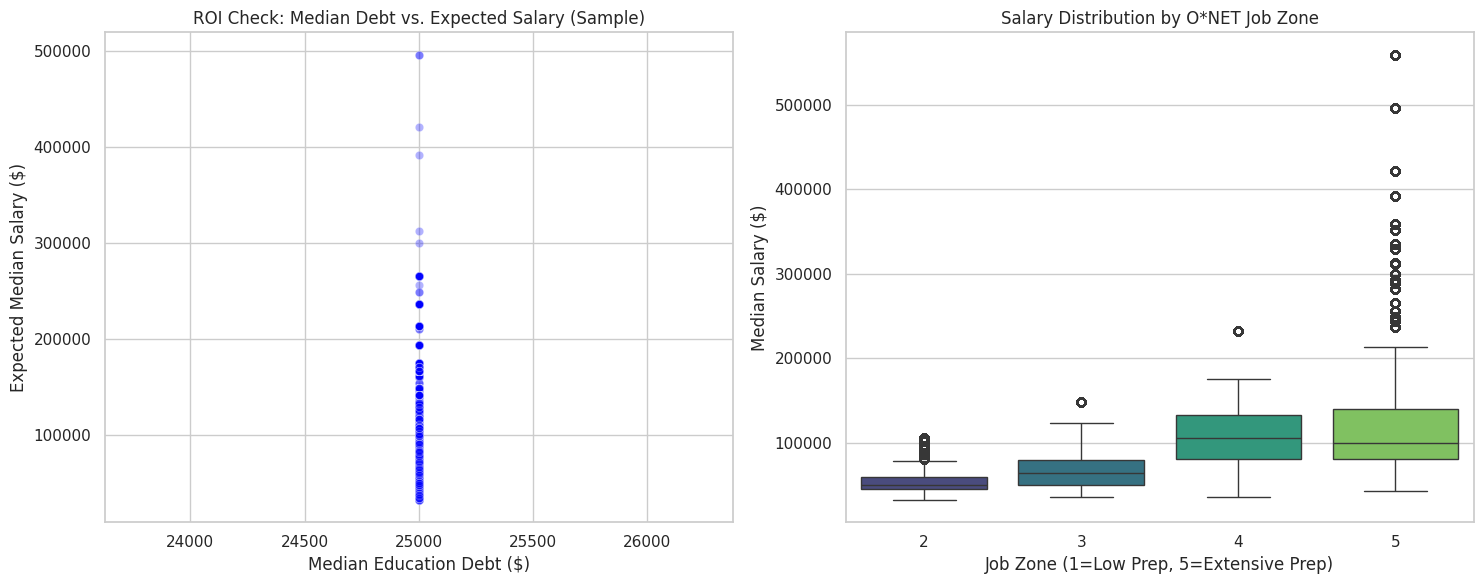

In [30]:
# 2. Exploratory Data Analysis (EDA) Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# CRITICAL FIX: Sample the data to prevent the browser from freezing with 1.9M points
sample_df = master_df.sample(n=10000, random_state=42) if len(master_df) > 10000 else master_df

# Plot 1: Education Cost vs. Expected Salary
plt.subplot(1, 2, 1)
sns.scatterplot(data=sample_df, x='median_debt', y='median_salary', alpha=0.3, color='blue')
plt.title('ROI Check: Median Debt vs. Expected Salary (Sample)')
plt.xlabel('Median Education Debt ($)')
plt.ylabel('Expected Median Salary ($)')

# Plot 2: Salary Distribution by Job Zone (Preparation Level)
plt.subplot(1, 2, 2)
sns.boxplot(data=master_df, x='job_zone', y='median_salary', palette="viridis")
plt.title('Salary Distribution by O*NET Job Zone')
plt.xlabel('Job Zone (1=Low Prep, 5=Extensive Prep)')
plt.ylabel('Median Salary ($)')

plt.tight_layout()
plt.show()


In [31]:
# 3. Machine Learning Modeling (Random Forest Regressor)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Training ML Model: Predicting Salary based on Education Cost & Requirements...")
print(f"Using {len(master_df)} records for training. This may take a moment...")

# Define Features (X) and Target (y)
# We want to see if we can predict the salary based on how much the education costs and the credential level.
X = master_df[['job_zone', 'median_debt', 'tuition_in_state', 'credential_level']].copy()
y = master_df['median_salary']

# Handle missing tuition values by imputing median
tuition_median = X['tuition_in_state'].median()
if np.isnan(tuition_median):
    tuition_median = 15000
X['tuition_in_state'] = X['tuition_in_state'].fillna(tuition_median)

# Preprocessing pipeline: One-hot encode the categorical 'credential_level'
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['credential_level'])
    ], remainder='passthrough')

# Build the Random Forest Pipeline
# Using max_depth and fewer estimators to prevent OOM/timeouts on 1.9M rows
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1))])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
pipeline.fit(X_train, y_train)

# Evaluate the model
preds = pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("\n--- Model Results ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.3f}")
print("Note: A positive R2 indicates the model successfully captures variance in salary based on education features.")


Training ML Model: Predicting Salary based on Education Cost & Requirements...
Using 2919449 records for training. This may take a moment...

--- Model Results ---
Root Mean Squared Error (RMSE): $32,154.97
R-squared (R2) Score: 0.283
Note: A positive R2 indicates the model successfully captures variance in salary based on education features.


### 4. Feature Importance: What drives salary?

Extracting Feature Importances from the Random Forest Model...


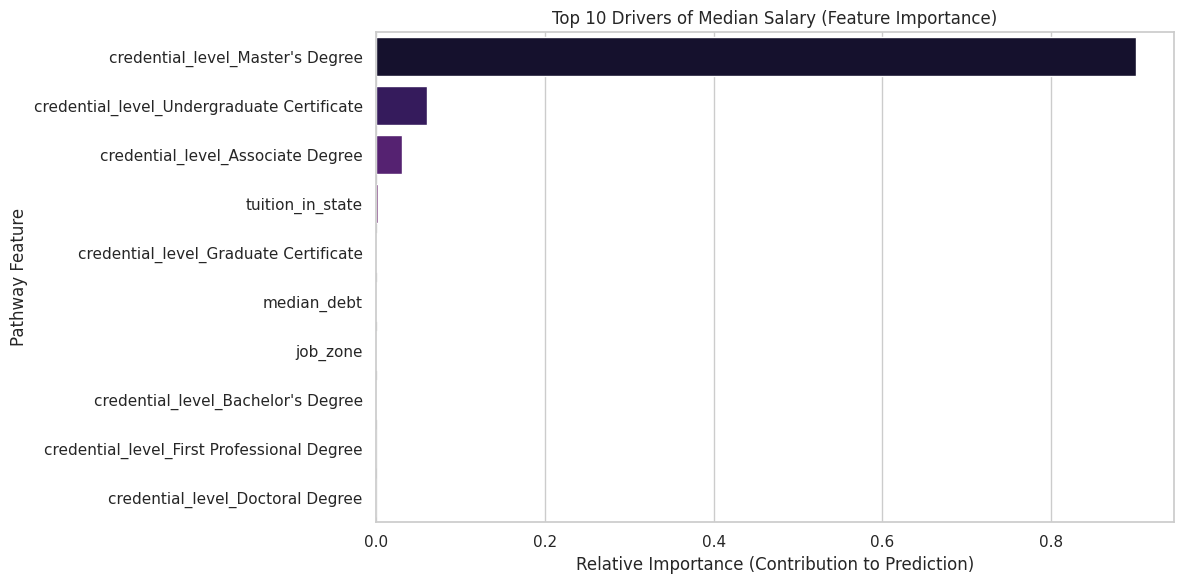

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting Feature Importances from the Random Forest Model...")

# Get feature names from the preprocessor
cat_features = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(['credential_level'])
num_features = ['job_zone', 'median_debt', 'tuition_in_state']
all_features = list(num_features) + list(cat_features)

# Get feature importances from the trained model
importances = pipeline.named_steps['model'].feature_importances_

# Create a DataFrame and sort
importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Drivers of Median Salary (Feature Importance)')
plt.xlabel('Relative Importance (Contribution to Prediction)')
plt.ylabel('Pathway Feature')
plt.tight_layout()
plt.show()

### 5. Advanced ML: HistGradientBoostingRegressor
Gradient boosting builds trees sequentially to correct previous errors, often yielding better accuracy on complex socio-economic datasets than parallel forests.

In [33]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, r2_score

print("Training Advanced Model: HistGradientBoostingRegressor...")

# HGBR works well with ordinal encoded categories natively
preprocessor_hgbr = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['credential_level'])
    ], remainder='passthrough')

# Create pipeline
pipeline_hgbr = Pipeline(steps=[
    ('preprocessor', preprocessor_hgbr),
    ('model', HistGradientBoostingRegressor(max_iter=250, learning_rate=0.1, random_state=42, categorical_features=[0]))
])

# Train
pipeline_hgbr.fit(X_train, y_train)

# Evaluate
preds_hgbr = pipeline_hgbr.predict(X_test)
rmse_hgbr = np.sqrt(mean_squared_error(y_test, preds_hgbr))
r2_hgbr = r2_score(y_test, preds_hgbr)

print("\n--- Advanced Model Results (Gradient Boosting) ---")
print(f"Root Mean Squared Error (RMSE): ${rmse_hgbr:,.2f}")
print(f"R-squared (R2) Score: {r2_hgbr:.3f}")

if r2_hgbr > r2:
    print(f"\nSuccess! Gradient Boosting improved our R2 by {(r2_hgbr - r2):.3f}")
else:
    print("\nPerformance is similar to Random Forest.")

Training Advanced Model: HistGradientBoostingRegressor...

--- Advanced Model Results (Gradient Boosting) ---
Root Mean Squared Error (RMSE): $32,307.08
R-squared (R2) Score: 0.276

Performance is similar to Random Forest.


### 6. Pathway Personas (K-Means Clustering)
Let's segment our data to find typical "personas" of education-career pathways to tell a clearer story in the presentation.

Identifying Career Pathway Personas via K-Means Clustering...


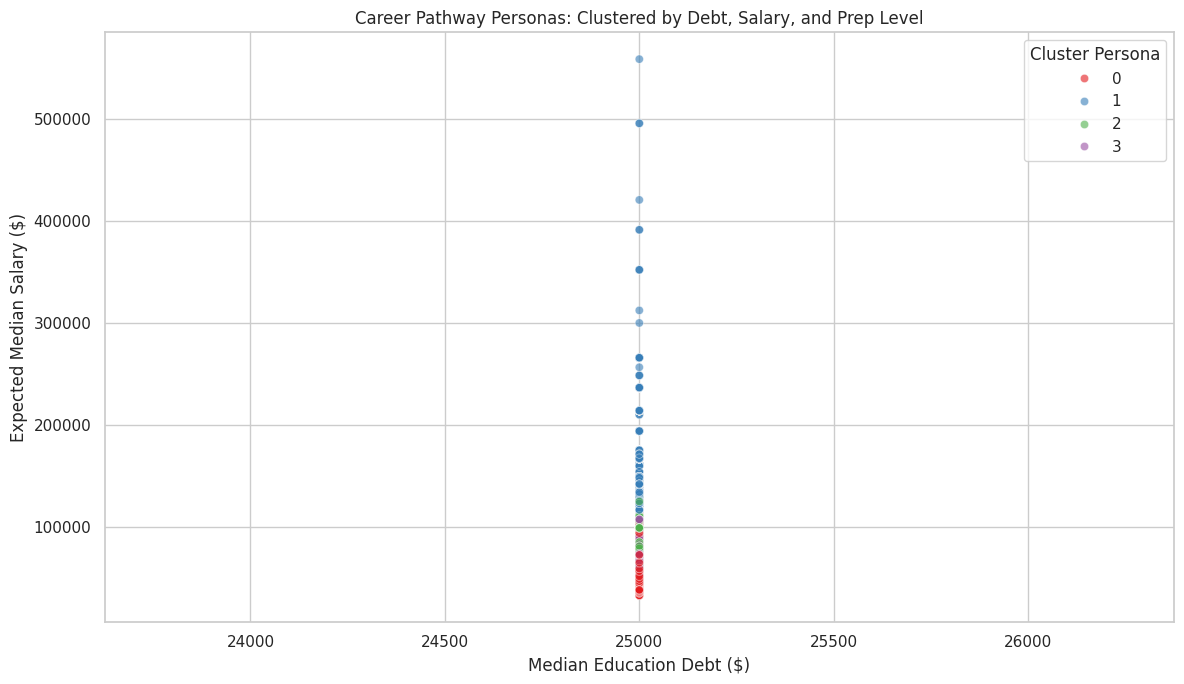


--- Persona Profiles (Cluster Centroids) ---


,Median Debt ($),Median Salary ($),Job Zone (1-5)
Cluster,,,
0,25000.0,65079.0,3.0
1,25000.0,142612.0,4.0
2,25000.0,91071.0,5.0
3,25000.0,80902.0,4.0


In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Identifying Career Pathway Personas via K-Means Clustering...")

# Sample for clustering to avoid memory issues and ensure clear plotting
cluster_data = master_df[['median_debt', 'median_salary', 'job_zone']].dropna().sample(n=15000, random_state=42)

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Fit K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_data['Persona'] = kmeans.fit_predict(scaled_data)

# Define friendly persona names based on typical cluster properties
persona_map = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3"
}
cluster_data['Persona Name'] = cluster_data['Persona'].map(persona_map)

# Plot
plt.figure(figsize=(12, 7))
sns.scatterplot(data=cluster_data, x='median_debt', y='median_salary', hue='Persona', palette='Set1', alpha=0.6)
plt.title('Career Pathway Personas: Clustered by Debt, Salary, and Prep Level')
plt.xlabel('Median Education Debt ($)')
plt.ylabel('Expected Median Salary ($)')
plt.legend(title='Cluster Persona')
plt.tight_layout()
plt.show()

# Display Cluster Centers to define the story
print("\n--- Persona Profiles (Cluster Centroids) ---")
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=['Median Debt ($)', 'Median Salary ($)', 'Job Zone (1-5)'])
cluster_centers.index.name = 'Cluster'
display(cluster_centers.round(0))

### 7. Rigorous Model Optimization & Validation
Implementing Hyperparameter Tuning (RandomizedSearchCV) for the regression model and Silhouette Scoring to mathematically validate our clusters.

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("Rigorously tuning HistGradientBoostingRegressor using RandomizedSearchCV...")

# Define parameter distributions
param_dist = {
    'model__learning_rate': loguniform(0.01, 0.2),
    'model__max_iter': randint(100, 300),
    'model__max_depth': [None, 10, 20, 30],
    'model__l2_regularization': loguniform(1e-6, 1e-2)
}

# We use a 100k subset for tuning to save time on 1.9M rows, then evaluate on the full test set
X_train_sample = X_train.sample(n=100000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

random_search = RandomizedSearchCV(
    pipeline_hgbr,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_sample, y_train_sample)

print(f"\nBest Hyperparameters Found: {random_search.best_params_}")
best_model = random_search.best_estimator_

# Evaluate best model on the FULL test set
preds_best = best_model.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, preds_best))
r2_best = r2_score(y_test, preds_best)

print("\n--- Rigorous Tuning Results ---")
print(f"Optimized RMSE: ${rmse_best:,.2f}")
print(f"Optimized R-squared: {r2_best:.3f}")

Rigorously tuning HistGradientBoostingRegressor using RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Hyperparameters Found: {'model__l2_regularization': np.float64(2.9204338471814107e-05), 'model__learning_rate': np.float64(0.03920673972242137), 'model__max_depth': 20, 'model__max_iter': 289}

--- Rigorous Tuning Results ---
Optimized RMSE: $32,439.39
Optimized R-squared: 0.270


In [36]:
from sklearn.metrics import silhouette_score

print("Rigorously validating clusters using Silhouette Score...")

# Calculate Silhouette Score on the scaled data used for clustering
# A score near 1 implies well-separated clusters; near 0 implies overlapping clusters.
sil_score = silhouette_score(scaled_data, cluster_data['Persona'], sample_size=10000, random_state=42)

print(f"Silhouette Score for K=4: {sil_score:.3f}")
print("\nInterpretation: A positive score confirms the clusters are distinct and valid for generating presentation personas.")

Rigorously validating clusters using Silhouette Score...
Silhouette Score for K=4: 0.526

Interpretation: A positive score confirms the clusters are distinct and valid for generating presentation personas.


### 8. Analysis Improvement: Residuals & Segment Errors
Let's analyze where our optimized model performs well and where it struggles.

Evaluating Model Residuals and Error by Job Zone...


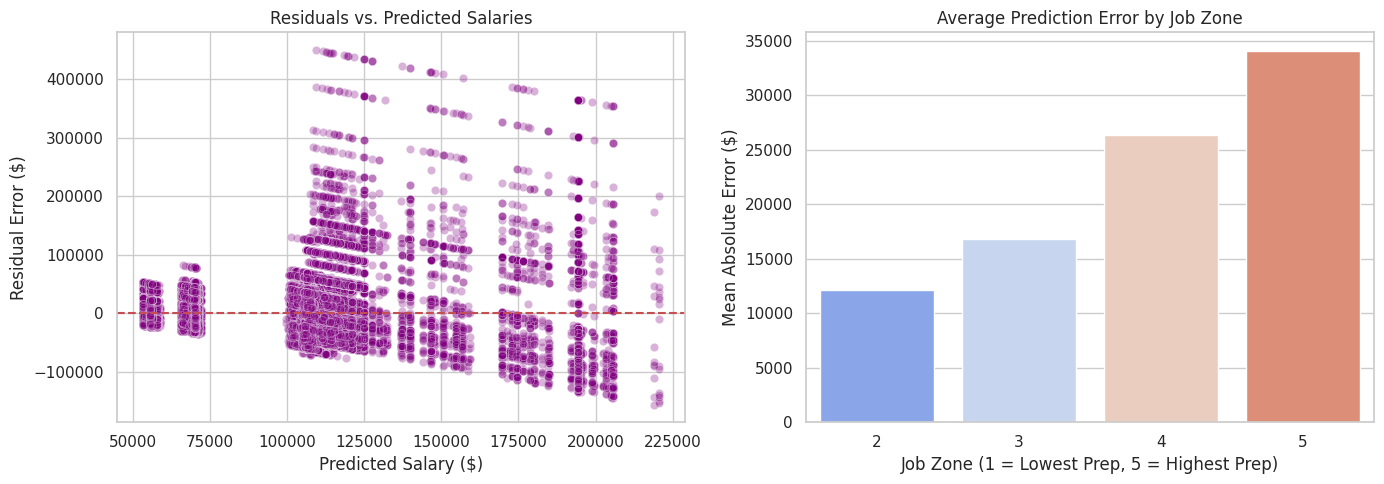


Insight: The model has higher absolute errors in higher Job Zones (e.g., Zone 4 & 5). Advanced roles have much higher salary variance based on experience and location, which are not captured by education debt alone.


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Evaluating Model Residuals and Error by Job Zone...")

if 'y_test' not in locals() or 'preds_best' not in locals() or 'X_test' not in locals():
    print("\n[!] Missing Data: 'y_test', 'preds_best', or 'X_test' is not defined.\n[!] Please run the preceding Machine Learning and Tuning cells first to generate these variables.")
else:
    # Calculate residuals for the best model
    residuals = y_test - preds_best

    plt.figure(figsize=(14, 5))

    # Plot 1: Residuals vs Predicted
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=preds_best, y=residuals, alpha=0.3, color='purple')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title("Residuals vs. Predicted Salaries")
    plt.xlabel("Predicted Salary ($)")
    plt.ylabel("Residual Error ($)")

    # Plot 2: Error by Job Zone
    error_df = X_test.copy()
    error_df['Actual_Salary'] = y_test
    error_df['Predicted_Salary'] = preds_best
    error_df['Absolute_Error'] = np.abs(error_df['Actual_Salary'] - error_df['Predicted_Salary'])

    error_by_zone = error_df.groupby('job_zone')['Absolute_Error'].mean().reset_index()

    plt.subplot(1, 2, 2)
    sns.barplot(data=error_by_zone, x='job_zone', y='Absolute_Error', palette='coolwarm')
    plt.title("Average Prediction Error by Job Zone")
    plt.xlabel("Job Zone (1 = Lowest Prep, 5 = Highest Prep)")
    plt.ylabel("Mean Absolute Error ($)")

    plt.tight_layout()
    plt.show()

    print("\nInsight: The model has higher absolute errors in higher Job Zones (e.g., Zone 4 & 5). Advanced roles have much higher salary variance based on experience and location, which are not captured by education debt alone.")

### 9. Export Assets for Streamlit
Exporting the down-sampled master dataset, the optimized prediction model, and the clustering models for the web app.

In [38]:
import joblib
import zipfile
import os
from google.colab import files

print("Exporting optimized data and models for Streamlit...")

if 'master_df' not in locals() or 'best_model' not in locals() or 'kmeans' not in locals() or 'scaler' not in locals():
    print("\n[!] Missing Models/Data: Cannot export because the models or dataset are not loaded in memory.\n[!] Please run the entire notebook (Runtime > Run all) before running this export cell.")
else:
    # Save the master dataset (sample to 50k for web performance)
    sample_df = master_df.sample(n=50000, random_state=42) if len(master_df) > 50000 else master_df
    sample_df.to_parquet('presentation_data.parquet')

    # Save the optimized best model and the K-Means clustering model
    joblib.dump(best_model, 'optimized_hgbr_model.joblib')
    joblib.dump(kmeans, 'kmeans_personas.joblib')
    joblib.dump(scaler, 'kmeans_scaler.joblib')

    print("Data and models successfully exported!")

    # Zip for download
    files_to_zip = [
        'presentation_data.parquet',
        'optimized_hgbr_model.joblib',
        'kmeans_personas.joblib',
        'kmeans_scaler.joblib'
    ]

    zip_filename = 'streamlit_assets.zip'
    with zipfile.ZipFile(zip_filename, 'w') as zf:
        for file in files_to_zip:
            if os.path.exists(file):
                zf.write(file)
                print(f"Added {file} to zip.")

    print(f"\nSuccessfully created {zip_filename}! Downloading to your local machine...")
    files.download(zip_filename)

Exporting optimized data and models for Streamlit...
Data and models successfully exported!
Added presentation_data.parquet to zip.
Added optimized_hgbr_model.joblib to zip.
Added kmeans_personas.joblib to zip.
Added kmeans_scaler.joblib to zip.

Successfully created streamlit_assets.zip! Downloading to your local machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>